# 🧠 Mental Health Intelligence Platform

## Phase 4 — Exploratory Data Analysis

### Workplace Analysis

Workplace culture plays a critical role in shaping employee mental health outcomes.

This notebook explores workplace characteristics reported by survey respondents, including organizational support, available resources, company size, and mental health policies.

Understanding these workplace factors provides valuable context for identifying organizational practices associated with better mental health outcomes.

---

### Objectives

This notebook aims to:

- Analyze workplace characteristics
- Explore organizational support programs
- Evaluate company mental health policies
- Investigate access to mental health resources
- Examine remote working practices

## Import Required Libraries

In [1]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np

import plotly.express as px
import plotly.graph_objects as go

pd.set_option("display.max_columns", None)

## Load Dataset

In [3]:
df = pd.read_csv("../../data/processed/harmonized_osmi_data.csv")

print(df.shape)

(3082, 70)


## Employment Status

Understanding whether respondents are self-employed provides context for interpreting workplace support.

Self-employed individuals often lack access to formal organizational mental health resources compared to employees working within larger companies.

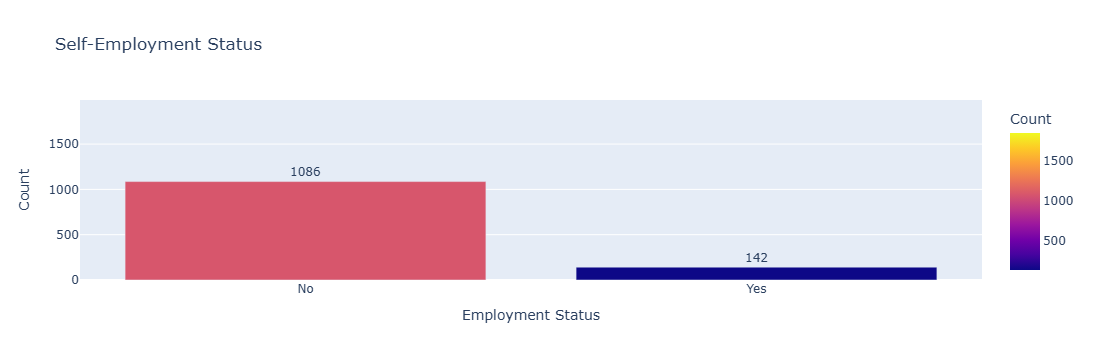

In [5]:
employment = (
    df["self_employed"]
    .value_counts(dropna=False)
    .reset_index()
)

employment.columns = ["Employment Status", "Count"]

fig = px.bar(
    employment,
    x="Employment Status",
    y="Count",
    color="Count",
    text="Count",
    title="Self-Employment Status"
)

fig.update_traces(textposition="outside")

fig.show()

## Technology Company Representation

Since the OSMI survey primarily targets the technology sector, it is important to understand how many respondents work within technology companies.

This provides context for interpreting workplace policies and mental health support.

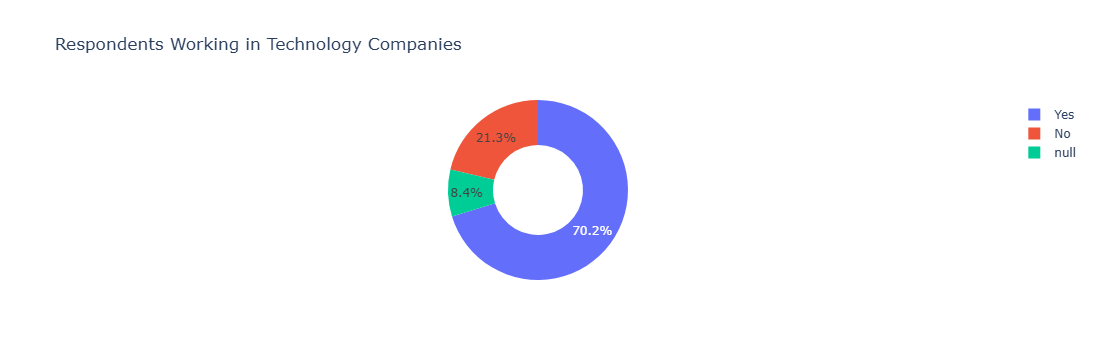

In [7]:
tech = (
    df["tech_company"]
    .value_counts(dropna=False)
    .reset_index()
)

tech.columns = ["Technology Company", "Count"]

fig = px.pie(
    tech,
    names="Technology Company",
    values="Count",
    hole=0.5,
    title="Respondents Working in Technology Companies"
)

fig.show()

## Availability of Mental Health Benefits

Access to employer-sponsored mental health benefits is an important indicator of organizational commitment to employee well-being.

This section evaluates how frequently respondents report receiving mental health benefits through their employer.

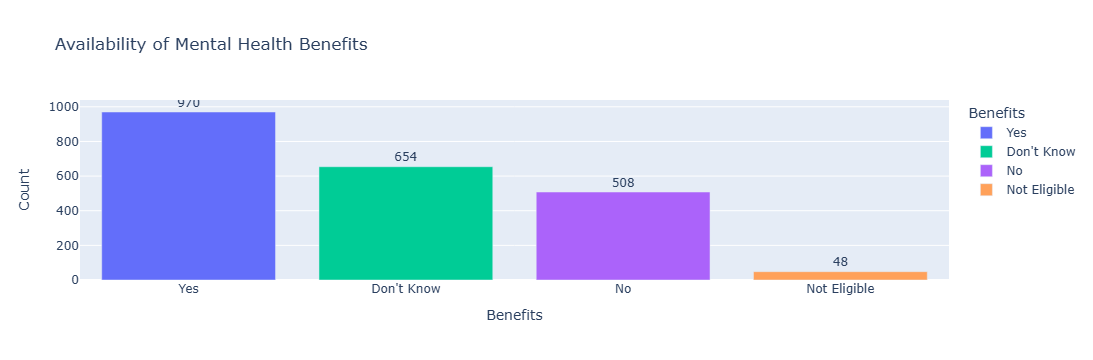

In [9]:
benefits = (
    df["benefits"]
    .value_counts(dropna=False)
    .reset_index()
)

benefits.columns = ["Benefits", "Count"]

fig = px.bar(
    benefits,
    x="Benefits",
    y="Count",
    color="Benefits",
    text="Count",
    title="Availability of Mental Health Benefits"
)

fig.update_traces(textposition="outside")

fig.show()

## Mental Health Care Options

Organizations may provide access to counseling, therapy, or other mental health care services.

Availability of these resources reflects the level of organizational investment in employee well-being.

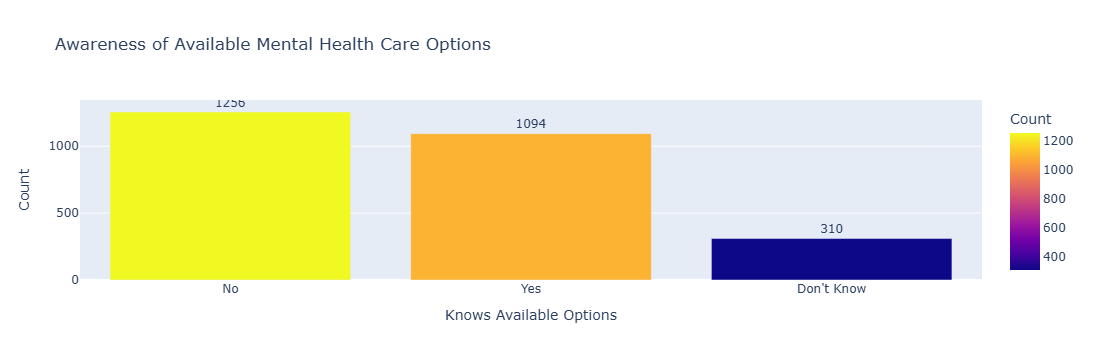

In [12]:
care = (
    df["know_options"]
    .value_counts(dropna=False)
    .reset_index()
)

care.columns = ["Knows Available Options", "Count"]

fig = px.bar(
    care,
    x="Knows Available Options",
    y="Count",
    color="Count",
    text="Count",
    title="Awareness of Available Mental Health Care Options"
)

fig.update_traces(textposition="outside")

fig.show()

## Workplace Mental Health Resources

Providing employees with accessible mental health resources is an important indicator of an organization's commitment to employee well-being.

Examples of such resources include:

- Employee Assistance Programs (EAPs)
- Counseling Services
- Mental Health Portals
- Internal Support Resources

This section examines how commonly respondents report having access to these workplace resources.

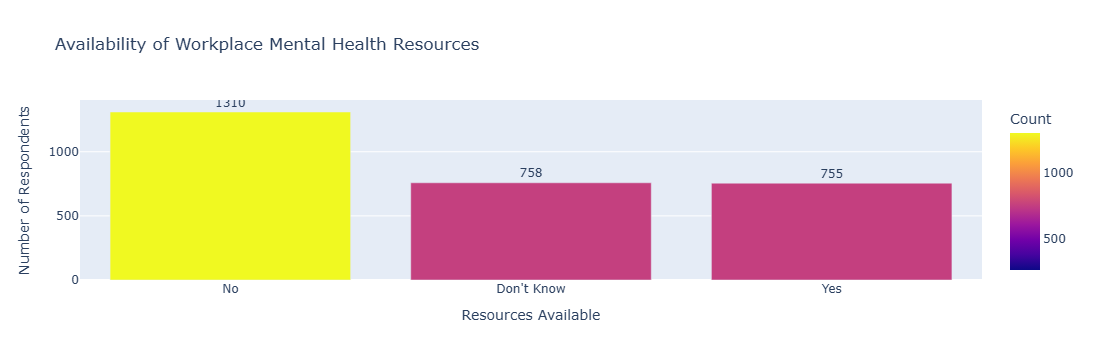

In [13]:
resources = (
    df["resources"]
    .value_counts(dropna=False)
    .reset_index()
)

resources.columns = [
    "Mental Health Resources",
    "Count"
]

fig = px.bar(
    resources,
    x="Mental Health Resources",
    y="Count",
    color="Count",
    text="Count",
    title="Availability of Workplace Mental Health Resources"
)

fig.update_traces(textposition="outside")

fig.update_layout(
    xaxis_title="Resources Available",
    yaxis_title="Number of Respondents"
)

fig.show()

## Formal Discussions About Mental Health

Organizations that openly discuss mental health often contribute to healthier workplace cultures by reducing stigma and increasing awareness.

This analysis examines whether respondents report that their employers conduct formal discussions regarding mental health.

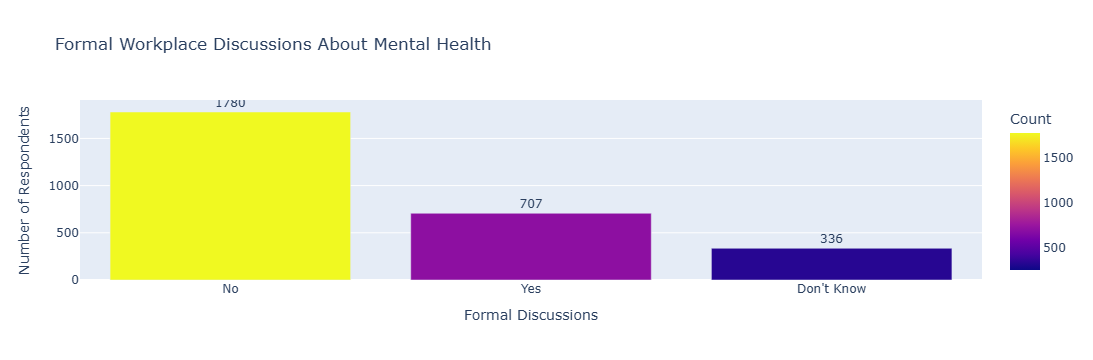

In [15]:
discussion = (
    df["formal_discussion"]
    .value_counts(dropna=False)
    .reset_index()
)

discussion.columns = [
    "Formal Discussion",
    "Count"
]

fig = px.bar(
    discussion,
    x="Formal Discussion",
    y="Count",
    color="Count",
    text="Count",
    title="Formal Workplace Discussions About Mental Health"
)

fig.update_traces(textposition="outside")

fig.update_layout(
    xaxis_title="Formal Discussions",
    yaxis_title="Number of Respondents"
)

fig.show()

## Workplace Anonymity

Employees are generally more willing to seek mental health support when confidentiality is maintained.

This section explores respondent perceptions regarding anonymity when accessing workplace mental health resources.

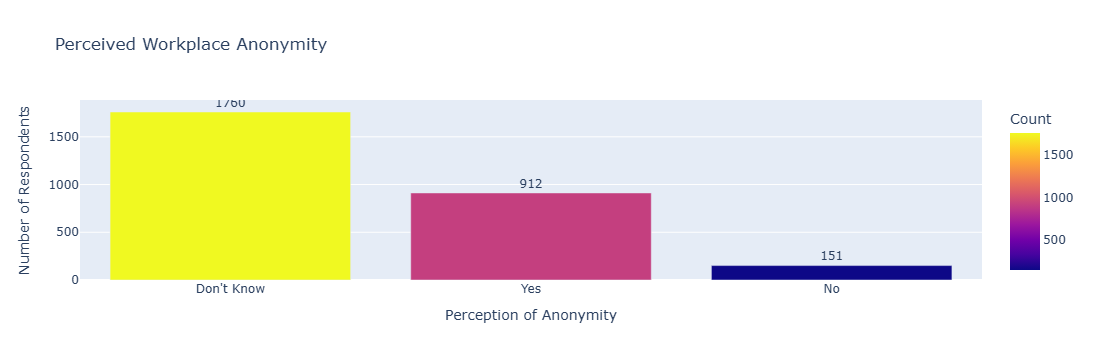

In [16]:
anon = (
    df["anonymity"]
    .value_counts(dropna=False)
    .reset_index()
)

anon.columns = [
    "Anonymity",
    "Count"
]

fig = px.bar(
    anon,
    x="Anonymity",
    y="Count",
    color="Count",
    text="Count",
    title="Perceived Workplace Anonymity"
)

fig.update_traces(textposition="outside")

fig.update_layout(
    xaxis_title="Perception of Anonymity",
    yaxis_title="Number of Respondents"
)

fig.show()

## Ease of Taking Mental Health Leave

One important indicator of organizational support is how comfortable employees feel taking leave for mental health reasons.

This section explores respondents' perceptions regarding the ease of requesting mental health leave.

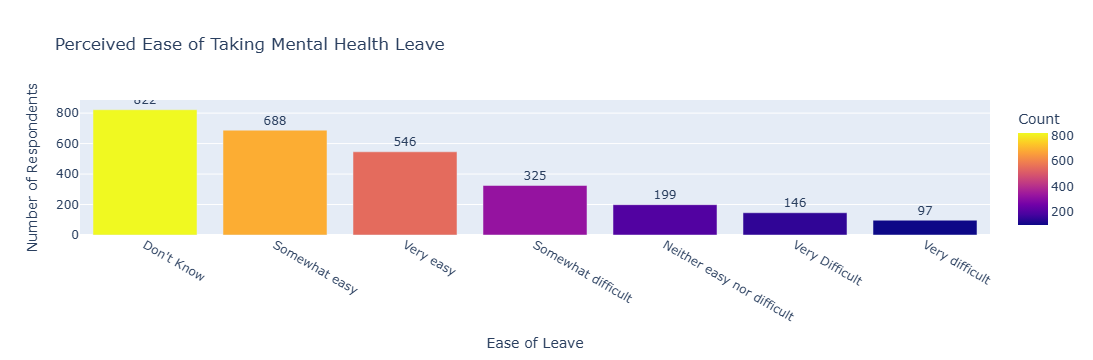

In [18]:
leave = (
    df["leave_ease"]
    .value_counts(dropna=False)
    .reset_index()
)

leave.columns = [
    "Ease of Leave",
    "Count"
]

fig = px.bar(
    leave,
    x="Ease of Leave",
    y="Count",
    color="Count",
    text="Count",
    title="Perceived Ease of Taking Mental Health Leave"
)

fig.update_traces(textposition="outside")

fig.update_layout(
    xaxis_title="Ease of Leave",
    yaxis_title="Number of Respondents"
)

fig.show()

## Company Size vs Mental Health Benefits

Larger organizations often possess greater financial and organizational capacity to provide employee wellness initiatives.

This section investigates whether company size influences the availability of employer-sponsored mental health benefits.

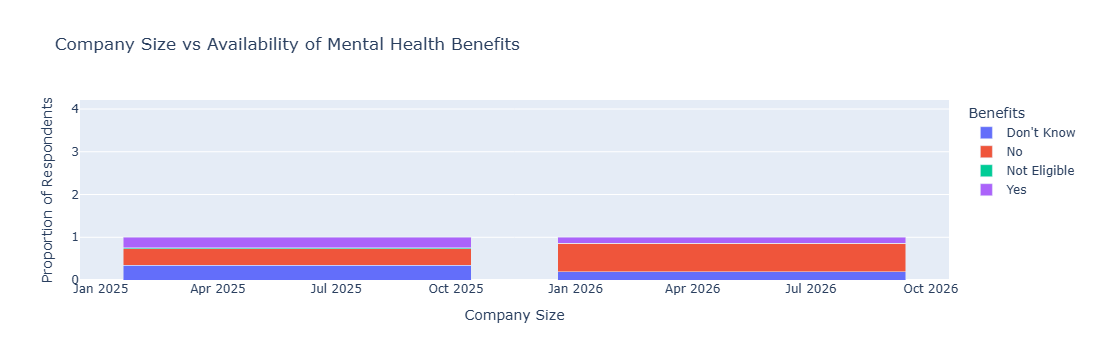

In [20]:
cross = pd.crosstab(
    df["no_employees"],
    df["benefits"],
    normalize="index"
)

cross = (
    cross
    .reset_index()
    .melt(
        id_vars="no_employees",
        var_name="Benefits",
        value_name="Percentage"
    )
)

fig = px.bar(
    cross,
    x="no_employees",
    y="Percentage",
    color="Benefits",
    barmode="stack",
    title="Company Size vs Availability of Mental Health Benefits"
)

fig.update_layout(
    xaxis_title="Company Size",
    yaxis_title="Proportion of Respondents"
)

fig.show()